In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# load the dataset
data = pd.read_csv("/content/drive/MyDrive/ML_Predictive_Models/dataset.csv")
# show the dataset
data.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


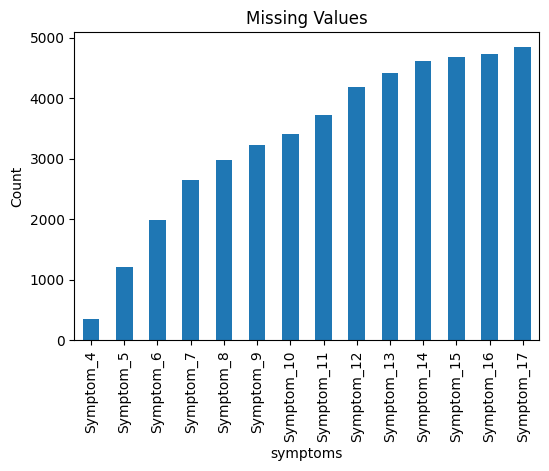

In [ ]:
import matplotlib.pyplot as plt
missing = data.isnull().sum()

plt.figure(figsize=(6, 4))
missing [missing > 0].sort_values().plot(kind='bar')
plt.title('Missing Values')
plt.ylabel('Count')
plt.xlabel('symptoms')
plt.show()

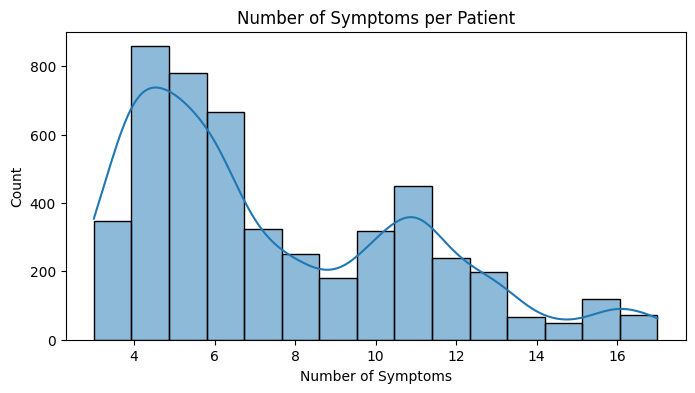

In [ ]:
symptom_cols = [col for col in data.columns if 'Symptom' in col]

symptom_count_per_patient = data[symptom_cols].notnull().sum(axis=1)

plt.figure(figsize=(8,4))
sns.histplot(symptom_count_per_patient, bins=15, kde=True)
plt.title("Number of Symptoms per Patient")
plt.xlabel("Number of Symptoms")
plt.show()

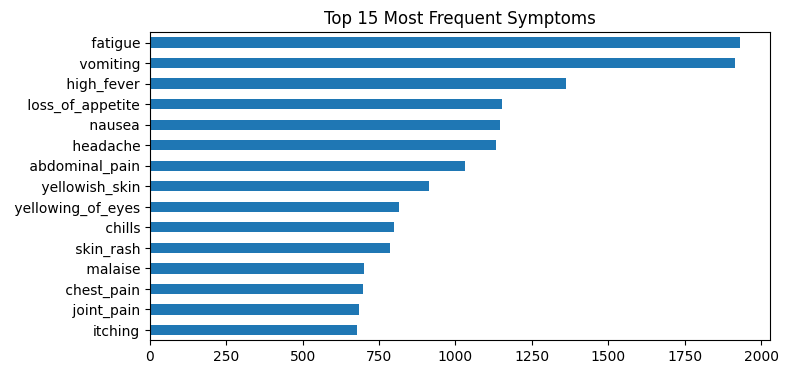

In [ ]:
all_symptoms = pd.Series(data[symptom_cols].values.ravel())
all_symptoms = all_symptoms.dropna()

top_symptoms = all_symptoms.value_counts().head(15)

plt.figure(figsize=(8,4))
top_symptoms.sort_values().plot(kind='barh')
plt.title("Top 15 Most Frequent Symptoms")
plt.show()

In [ ]:
all_symptoms = pd.Series(data[symptom_cols].values.ravel())
all_symptoms = all_symptoms.dropna().str.strip()
all_symptoms = all_symptoms[all_symptoms != '']
print("Number of unique symptoms:", all_symptoms.nunique())
print("Number of unique diseases:", data['Disease'].nunique())

Number of unique symptoms: 131
Number of unique diseases: 41


# **Preprocessing Data**


- Defining the target variable (Disease) and input features (Symptoms).
- Filling missing symptom values to preserve all records.
- Transforming symptom data into binary features using MultiLabelBinarizer.
- Encoding disease labels into numerical form using LabelEncoder.
- Splitting the dataset into training and testing sets for model evaluation.

In [ ]:
#Define target (Disease)
y = data['Disease']
symptom_cols = [col for col in data.columns if 'Symptom' in col]

print("target shape:", y.shape)
print("symptom columns:", len(symptom_cols))

target shape: (4920,)
symptom columns: 17


In [ ]:
#Fill missing values
data[symptom_cols] = data[symptom_cols].fillna('')

print("missing values after filling:", data[symptom_cols].isnull().sum().sum())

missing values after filling: 0


In [ ]:
#Collect symptoms into list per patient
symptoms_list = data[symptom_cols].apply(
    lambda row: [s.strip() for s in row if s.strip() != ''], axis=1
)
print(symptoms_list.head())

0    [itching, skin_rash, nodal_skin_eruptions, dis...
1    [skin_rash, nodal_skin_eruptions, dischromic _...
2    [itching, nodal_skin_eruptions, dischromic _pa...
3            [itching, skin_rash, dischromic _patches]
4           [itching, skin_rash, nodal_skin_eruptions]
dtype: object


In [ ]:
# 5.4 MultiLabelBinarizer
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
x = pd.DataFrame(
    mlb.fit_transform(symptoms_list),
    columns=mlb.classes_,
    index=data.index
)
print("x shape:", x.shape)

x shape: (4920, 131)


In [ ]:
# 5.5 LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_[:5], "...")
print("y_encoded shape:", y_encoded.shape)

Classes: ['(vertigo) Paroymsal  Positional Vertigo' 'AIDS' 'Acne'
 'Alcoholic hepatitis' 'Allergy'] ...
y_encoded shape: (4920,)


In [ ]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 4616


In [ ]:
combined = x.copy()
combined['Disease'] = y_encoded
print("Unique feature patterns:", combined.drop('Disease', axis=1).drop_duplicates().shape[0])
print("Total samples:", combined.shape[0])

Unique feature patterns: 304
Total samples: 4920


In [ ]:
combined = x.copy()
combined['Disease'] = y_encoded

combined = combined.drop_duplicates()

x_clean = combined.drop('Disease', axis=1)
y_clean = combined['Disease']

In [ ]:
# 5.7 Train/Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print("Train size:", x_train.shape)
print("Test size:", x_test.shape)

Train size: (243, 131)
Test size: (61, 131)


# **Training Models**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(x_train, y_train)
y_pred_knn = KNN_model.predict(x_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 1.0


In [ ]:
from sklearn.svm import SVC

SVM_model = SVC(kernel='linear', random_state=42)
SVM_model.fit(x_train, y_train)
y_pred_svm = SVM_model.predict(x_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF_model = RandomForestClassifier(random_state=42)
RF_model.fit(x_train, y_train)
y_pred_rf = RF_model.predict(x_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 1.0


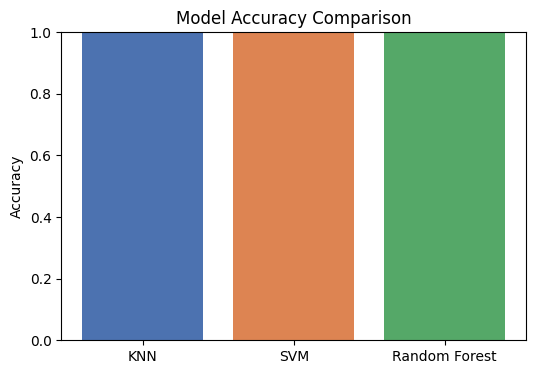

In [ ]:
models = ['KNN', 'SVM', 'Random Forest']
scores = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(6, 4))
plt.bar(models, scores, color=['#4C72B0','#DD8452','#55A868'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.show()

**Evaluation**


In [ ]:
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf,
      target_names=le.classes_))


Classification Report - Random Forest
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         2
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      1.00      1.00         2
                            Common Cold       1.00      1.00      1.00

In [ ]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(y_test, y_pred_rf, average='macro')
weighted_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Macro F1 Score:   ", round(macro_f1, 4))
print("Weighted F1 Score:", round(weighted_f1, 4))

Macro F1 Score:    1.0
Weighted F1 Score: 1.0


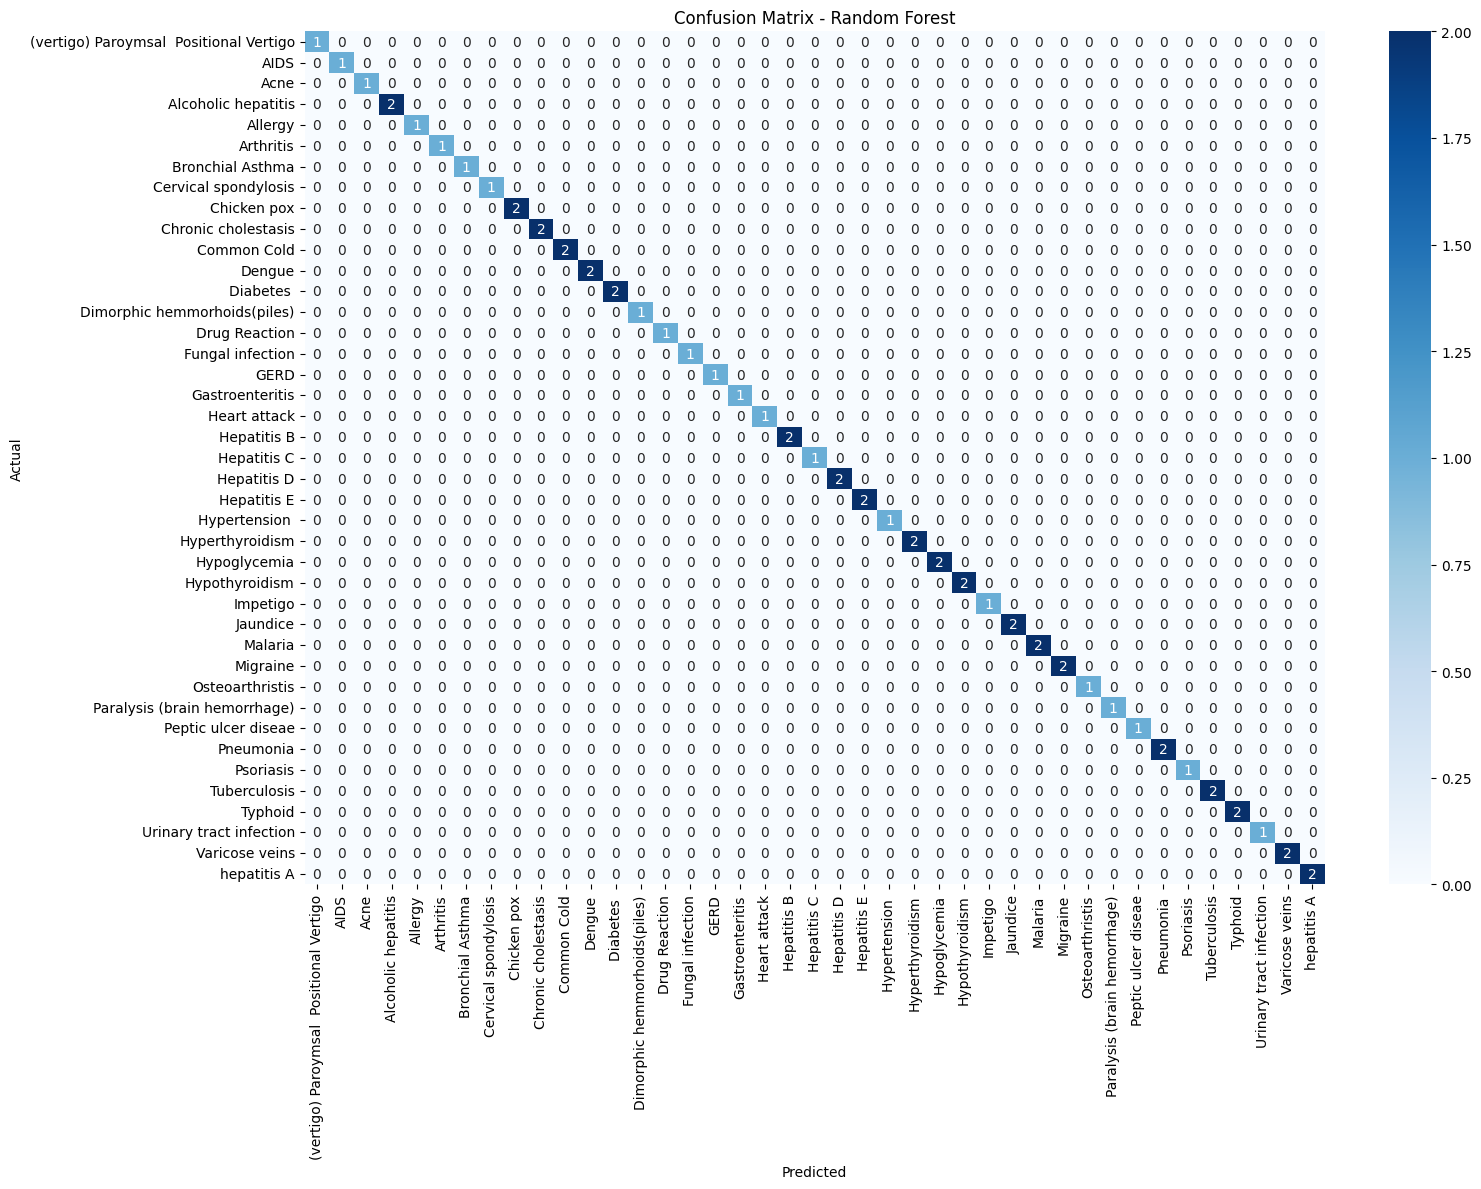

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(16, 12))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
